# CrossSO Demo

GPU inference with sparse high-resolution observations and text retrieval.


## Workflow

1. Resolve project or Hugging Face resources.
2. Run the Router and Predictor on one scene.
3. Browse a curated six-query retrieval gallery.


In [1]:
from __future__ import annotations

import os
import sys
import time
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from PIL import Image, ImageDraw, ImageEnhance
from matplotlib.patches import Rectangle

%matplotlib inline


def find_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "configs/zero.yaml").is_file() and (candidate / "src/crossso").is_dir():
            return candidate
    raise FileNotFoundError("Run this Notebook inside the CrossSO workspace")


ROOT = find_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "src"))
OUTPUT_DIR = ROOT / "outputs/notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = os.environ.get("CROSSSO_DEVICE", "cuda:0" if torch.cuda.is_available() else "cpu")
SEED = 37
np.random.seed(SEED)
torch.manual_seed(SEED)

COLORS = {
    "blue": "#27A6D1",
    "purple": "#7F6AA5",
    "green": "#2EAD72",
    "gray": "#68727D",
}
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

display(pd.DataFrame([{"item": "device", "value": DEVICE}]))


,item,value
0,device,cuda:0


## 1. Resources

Install once with `pip install -e ".[eval]"`.

Use `weights` and `data`, or set the two Hugging Face repository variables below. DINOv2 and CLIP use pinned upstream revisions.


In [2]:
def resolve_resource(
    relative_path: str,
    directory_env: str,
    repo_env: str,
    repo_type: str,
    default_repo: str | None = None,
) -> tuple[Path, str]:
    directory = Path(os.environ.get(directory_env, ROOT / relative_path)).expanduser()
    if directory.exists():
        return directory.resolve(), "local"

    repo_id = os.environ.get(repo_env, default_repo)
    if not repo_id:
        raise FileNotFoundError(f"Missing {relative_path}; set {repo_env}")
    from huggingface_hub import snapshot_download

    return Path(snapshot_download(repo_id=repo_id, repo_type=repo_type)), "huggingface"


WEIGHTS_DIR, WEIGHT_SOURCE = resolve_resource(
    "weights", "CROSSSO_WEIGHTS_DIR", "CROSSSO_MODEL_REPO", "model",
    default_repo="xiehaoai/CrossSO",
)
DATA_DIR, DATA_SOURCE = resolve_resource(
    "data/sentinel2-naip", "CROSSSO_DATA_DIR", "CROSSSO_DATASET_REPO", "dataset"
)


def resolve_upstream(
    name: str,
    repo_id: str,
    revision: str,
    files: list[str],
) -> tuple[Path, str]:
    local = WEIGHTS_DIR / name
    if local.is_dir():
        return local, "local"
    from huggingface_hub import snapshot_download
    from huggingface_hub.utils import disable_progress_bars

    disable_progress_bars()
    return Path(snapshot_download(
        repo_id=repo_id,
        revision=revision,
        allow_patterns=files,
        max_workers=4,
    )), repo_id


DINOV2_REPO = "facebook/dinov2-with-registers-base"
DINOV2_REVISION = "a1d738ccfa7ae170945f210395d99dde8adb1805"
CLIP_REPO = "openai/clip-vit-base-patch32"
CLIP_REVISION = "3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268"
DINOV2_DIR, DINOV2_SOURCE = resolve_upstream(
    "dinov2-with-registers-base",
    DINOV2_REPO,
    DINOV2_REVISION,
    ["config.json", "model.safetensors", "preprocessor_config.json"],
)
CLIP_DIR, CLIP_SOURCE = resolve_upstream(
    "clip-vit-base-patch32",
    CLIP_REPO,
    CLIP_REVISION,
    [
        "config.json",
        "merges.txt",
        "pytorch_model.bin",
        "special_tokens_map.json",
        "tokenizer.json",
        "tokenizer_config.json",
        "vocab.json",
    ],
)

display(pd.DataFrame([
    {"resource": "weights", "source": WEIGHT_SOURCE},
    {"resource": "dataset", "source": DATA_SOURCE},
    {"resource": "DINOv2", "source": DINOV2_SOURCE},
    {"resource": "CLIP", "source": CLIP_SOURCE},
]))


,resource,source
0,weights,local
1,dataset,local
2,DINOv2,local
3,CLIP,local


## 2. Model

Load the fixed class budget, LR Router, Predictor, and LR fusion.


In [3]:
from crossso.data import CLASS_NAMES
from crossso.fusion import FileHRTileProvider, ZeroShotCrossSO, load_zero_shot_config


base_config = load_zero_shot_config(ROOT / "configs/zero.yaml")
model_config = replace(
    base_config,
    data_root=DATA_DIR,
    checkpoint=WEIGHTS_DIR / "vision_language_predictor.safetensors",
    router_checkpoint=WEIGHTS_DIR / "router.safetensors",
    dinov2_source=DINOV2_DIR,
    clip_text_source=CLIP_DIR,
)

required = (
    model_config.checkpoint,
    model_config.router_checkpoint,
    model_config.dinov2_source,
    model_config.clip_text_source,
)
missing = [item.name for item in required if not item.exists()]
if missing:
    raise FileNotFoundError(missing)

started = time.perf_counter()
model = ZeroShotCrossSO(model_config, device=DEVICE)
if model.device.type == "cuda":
    torch.cuda.synchronize(model.device)

print(f"Device: {model.device}; load time: {time.perf_counter() - started:.1f} s")
print(f"Pc total: {model.pc_policy.total_pc}; mean: {model.pc_policy.total_pc / len(CLASS_NAMES):.2f}")


Device: cuda:0; load time: 4.3 s
Pc total: 502; mean: 12.55


In [4]:
from crossso.fusion import LRFusion, load_lr_fusion_config


fusion_config = replace(
    load_lr_fusion_config(ROOT / "configs/zero.yaml"),
    artifact=WEIGHTS_DIR / "vision_language_predictor.safetensors",
)
fusion = LRFusion.from_config(fusion_config)
if fusion.class_names != tuple(CLASS_NAMES):
    raise ValueError("Fusion class order differs")
print(f"Fusion: {fusion.method}; pooling: {fusion.pooling}")


Fusion: robust_mad_tail; pooling: mean


## 3. Curated scene

Set `CROSSSO_DEMO`, or set both `CROSSSO_SAMPLE_INDEX` and `CROSSSO_QUERY`.


In [5]:
manifest_path = DATA_DIR / "test_loc_group.csv"
frame = pd.read_csv(manifest_path)

DEMO_CASES = {
    "highway": {"sample": 0, "query": "highway"},
    "airport": {"sample": 3507, "query": "airport"},
    "parkinglot": {"sample": 197, "query": "parkinglot"},
    "wetland": {"sample": 3056, "query": "wetland"},
    "forest": {"sample": 49, "query": "forest"},
}
demo_name = os.environ.get("CROSSSO_DEMO", "highway")
if demo_name not in DEMO_CASES:
    raise ValueError(f"Choose from {tuple(DEMO_CASES)}")

preset = DEMO_CASES[demo_name]
sample_index = int(os.environ.get("CROSSSO_SAMPLE_INDEX", preset["sample"]))
query_name = os.environ.get("CROSSSO_QUERY", preset["query"])
if sample_index not in range(len(frame)) or query_name not in CLASS_NAMES:
    raise ValueError((sample_index, query_name))


def data_path(value: str | Path) -> Path:
    relative = Path(str(value))
    if relative.is_absolute():
        raise ValueError("Dataset manifests must use dataset-root-relative paths")
    return DATA_DIR / relative


def row_paths(row: pd.Series) -> tuple[Path, list[Path]]:
    return data_path(row["lr_path"]), [data_path(row[f"hr_{index}"]) for index in range(100)]


sample_row = frame.iloc[sample_index]
lr_path, hr_paths = row_paths(sample_row)
query_index = CLASS_NAMES.index(query_name)

with Image.open(lr_path) as source:
    lr_preview = source.convert("RGB").copy()

display(pd.DataFrame([{
    "demo": demo_name,
    "sample": sample_index,
    "query": query_name,
}]))


,demo,sample,query
0,highway,0,highway


## 4. Inference

LR is always available. The Router reads a class-specific HR subset; the Predictor completes the remaining spatial features.


In [6]:
@torch.inference_mode()
def predict_scene(lr_path: Path, hr_paths: list[Path]) -> dict:
    provider = FileHRTileProvider(hr_paths, model_config.image_size)
    started = time.perf_counter()
    values = model.predict_classwise_pc_score_components(
        lr_path, provider, count_batch_size=2
    )
    router_scores = values["router_scores"].float().cpu()
    ranked = router_scores.argsort(descending=True).tolist()
    selected = {
        name: ranked[:int(model.pc_policy.values[index])]
        for index, name in enumerate(CLASS_NAMES)
    }
    predictor_scores = values["pred_hr_scores"].float().cpu()
    lr_by_pooling = {"mean": values["lr_mean_scores"].float().cpu()}
    return {
        "router_scores": router_scores,
        "selected": selected,
        "loaded": list(provider.loaded_indices),
        "tile_scores": values["pred_hr_tile_scores"].float().cpu(),
        "predictor_scores": predictor_scores,
        "lr_scores": lr_by_pooling[fusion.pooling],
        "final_scores": fusion.apply(
            predictor_scores, lr_by_pooling, class_names=CLASS_NAMES
        ),
        "seconds": time.perf_counter() - started,
    }


result = predict_scene(lr_path, hr_paths)
ranking = result["final_scores"].argsort(descending=True).tolist()
query_selected = result["selected"][query_name]

display(pd.DataFrame([{
    "query": query_name,
    "Pc": len(query_selected),
    "loaded tiles": len(set(result["loaded"])),
    "seconds": round(result["seconds"], 2),
}]))


,query,Pc,loaded tiles,seconds
0,highway,6,24,2.14


## 5. Overview

Green frames mark HR tiles read for the selected query. The full mosaic is loaded after timed sparse inference.


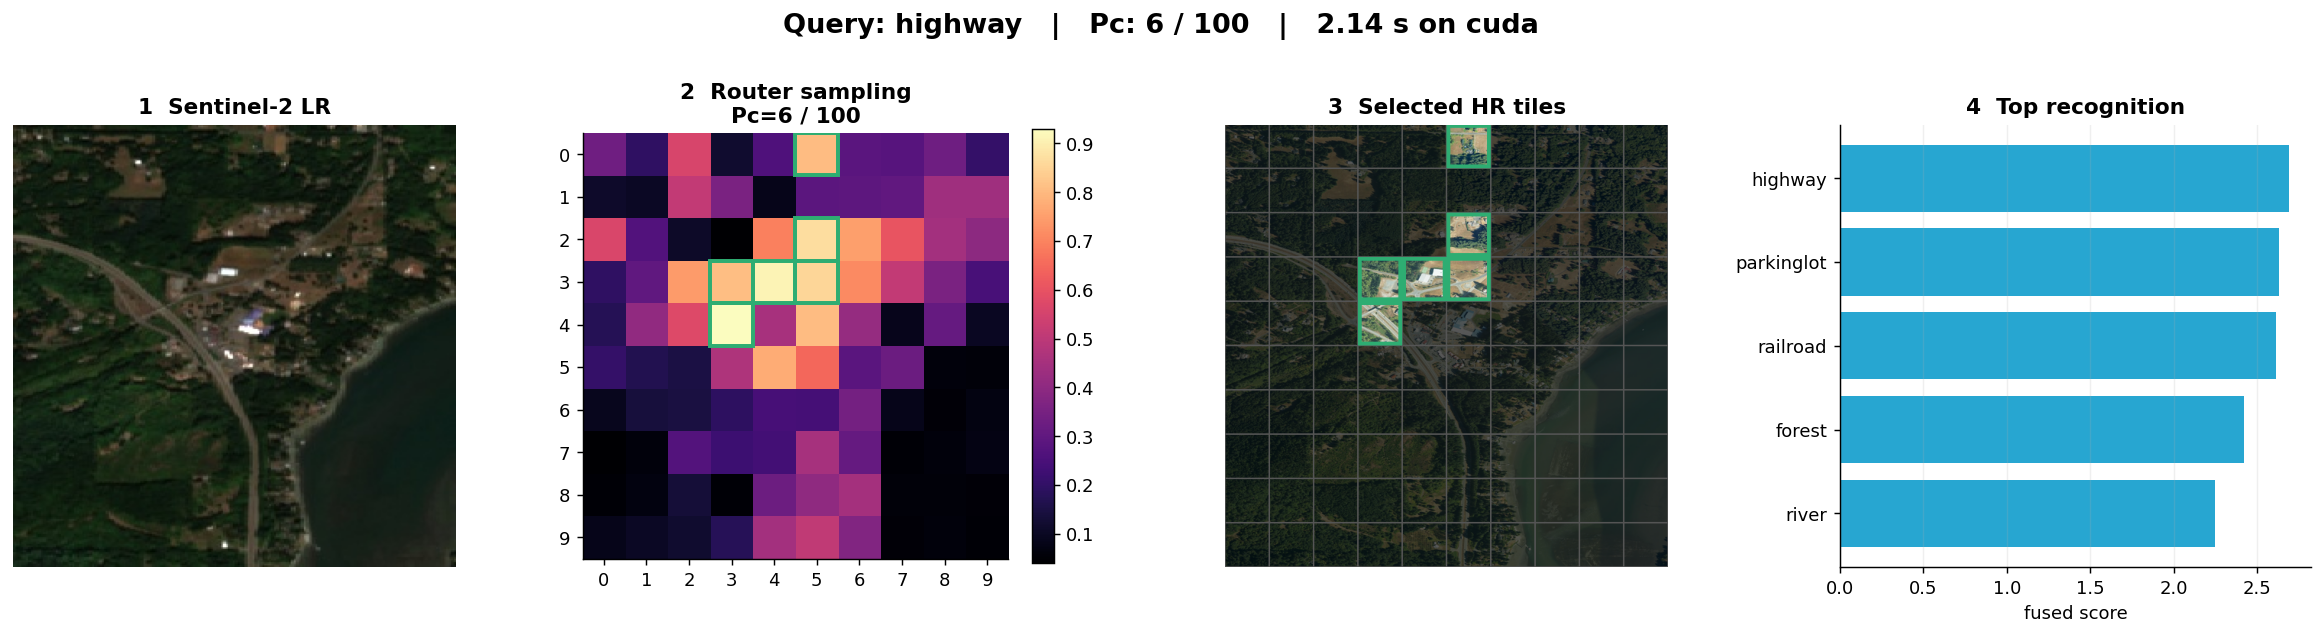

In [7]:
def draw_selected(ax, selected: list[int], color: str = COLORS["green"]) -> None:
    for index in selected:
        row, col = divmod(int(index), 10)
        ax.add_patch(Rectangle(
            (col - 0.5, row - 0.5), 1, 1,
            fill=False, edgecolor=color, linewidth=2.2,
        ))


def make_hr_mosaic(paths: list[Path], selected: list[int], tile_size: int = 58) -> Image.Image:
    chosen = set(selected)
    canvas = Image.new("RGB", (10 * tile_size, 10 * tile_size), "black")
    for index, path in enumerate(paths):
        with Image.open(path) as source_image:
            tile = source_image.convert("RGB").resize(
                (tile_size, tile_size), Image.Resampling.LANCZOS,
            )
        if index not in chosen:
            tile = ImageEnhance.Brightness(tile).enhance(0.35)
        canvas.paste(tile, ((index % 10) * tile_size, (index // 10) * tile_size))
    draw = ImageDraw.Draw(canvas)
    for index in range(100):
        x = (index % 10) * tile_size
        y = (index // 10) * tile_size
        draw.rectangle(
            (x, y, x + tile_size - 1, y + tile_size - 1),
            outline=(46, 173, 114) if index in chosen else (85, 85, 85),
            width=5 if index in chosen else 1,
        )
    return canvas


router_map = result["router_scores"].reshape(10, 10).numpy()
hr_mosaic = make_hr_mosaic(hr_paths, query_selected)
top_indices = ranking[:5]

fig, axes = plt.subplots(
    1, 4, figsize=(18, 4.7),
    gridspec_kw={"width_ratios": [1.0, 1.05, 1.2, 1.05]},
)
axes[0].imshow(lr_preview)
axes[0].set_title("1  Sentinel-2 LR")
axes[0].axis("off")

router_image = axes[1].imshow(router_map, cmap="magma")
draw_selected(axes[1], query_selected)
axes[1].set_title(f"2  Router sampling\nPc={len(query_selected)} / 100")
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))
fig.colorbar(router_image, ax=axes[1], fraction=0.046)

axes[2].imshow(hr_mosaic)
axes[2].set_title("3  Selected HR tiles")
axes[2].axis("off")

top_names = [CLASS_NAMES[index] for index in top_indices]
top_scores = [float(result["final_scores"][index]) for index in top_indices]
y = np.arange(len(top_names))
axes[3].barh(y, top_scores, color=COLORS["blue"])
axes[3].set_yticks(y, top_names)
axes[3].invert_yaxis()
axes[3].set_xlabel("fused score")
axes[3].set_title("4  Top recognition")
axes[3].grid(axis="x", alpha=0.2)

fig.suptitle(
    f"Query: {query_name}   |   Pc: {len(query_selected)} / 100   |   {result['seconds']:.2f} s on {model.device.type}",
    fontsize=15, fontweight="bold", y=1.03,
)
plt.tight_layout()
plt.show()


## 6. Predictor latent comparison

One-scene same-encoder comparison. Full HR features are used only as a visual reference after inference.


,scope,positions,same_encoder_cosine
0,all,100,0.8320
1,sampled,6,0.8728
2,completed,94,0.8294


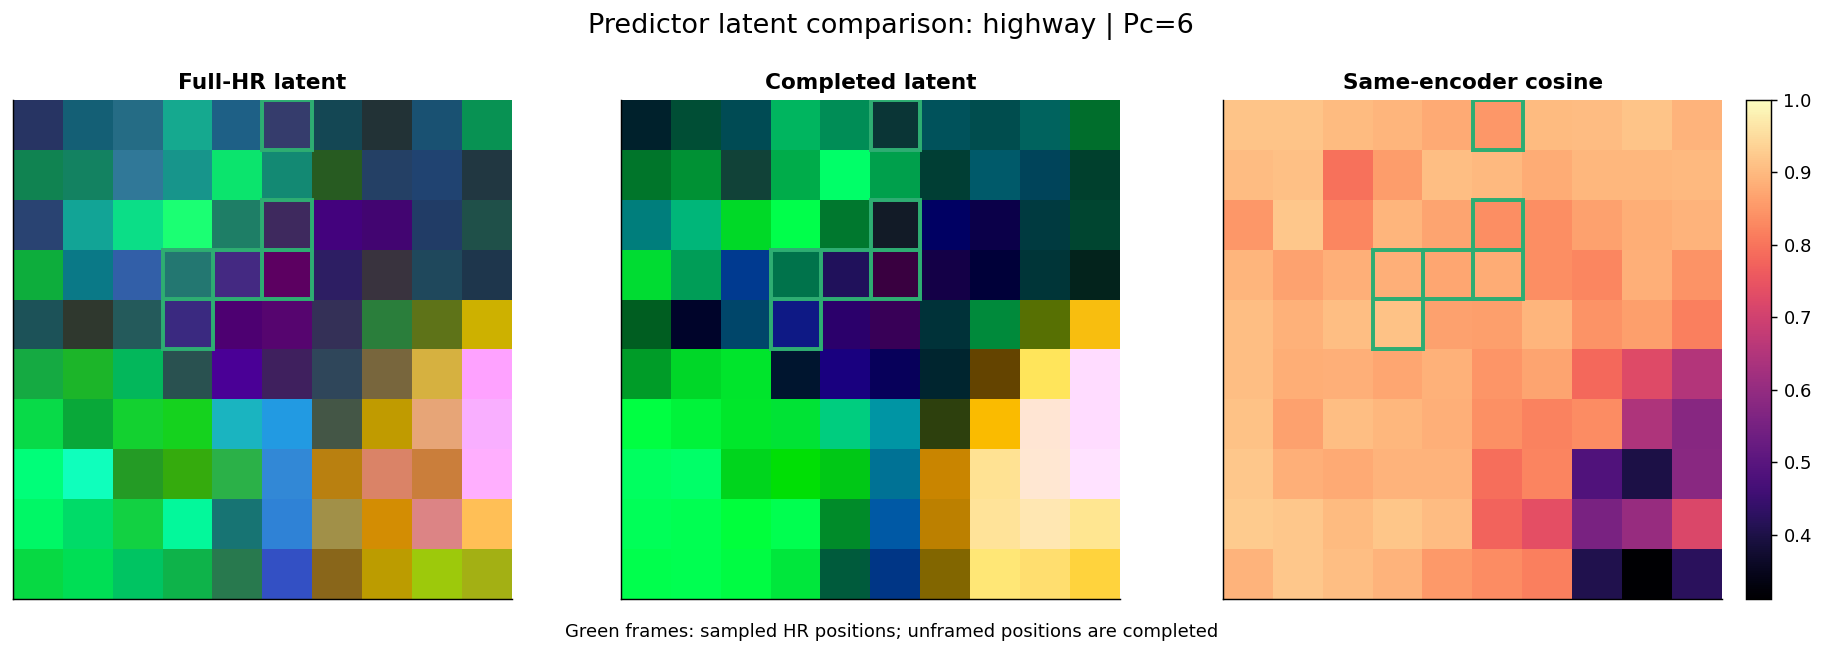

In [8]:
query_provider = FileHRTileProvider(hr_paths, model_config.image_size)
query_result = model.predict_pc_query(
    lr_path, query_provider, query_index, return_features=True
)
predicted_latent = query_result.predicted_features
if predicted_latent is None:
    raise RuntimeError("Missing Predictor features")
full_hr_latent = model.full_target_features(hr_paths).float().cpu()


def latent_rgb_pair(
    reference: torch.Tensor,
    predicted: torch.Tensor,
) -> tuple[np.ndarray, np.ndarray]:
    reference_tiles = reference.mean(dim=1)
    predicted_tiles = predicted.mean(dim=1)
    center = reference_tiles.mean(dim=0, keepdim=True)
    reference_centered = reference_tiles - center
    _, _, basis = torch.pca_lowrank(reference_centered, q=3, center=False)
    reference_pca = reference_centered @ basis[:, :3]
    predicted_pca = (predicted_tiles - center) @ basis[:, :3]
    low = torch.quantile(reference_pca, 0.02, dim=0, keepdim=True)
    high = torch.quantile(reference_pca, 0.98, dim=0, keepdim=True)

    def rgb(values: torch.Tensor) -> np.ndarray:
        values = ((values - low) / (high - low + 1e-8)).clamp(0, 1)
        return values.reshape(10, 10, 3).numpy()

    return rgb(reference_pca), rgb(predicted_pca)


tile_cosine = F.cosine_similarity(predicted_latent, full_hr_latent, dim=-1).mean(dim=1)
reference_rgb, predicted_rgb = latent_rgb_pair(full_hr_latent, predicted_latent)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8))
for ax, values, title in (
    (axes[0], reference_rgb, "Full-HR latent"),
    (axes[1], predicted_rgb, "Completed latent"),
):
    ax.imshow(values)
    ax.set_title(title)

image = axes[2].imshow(
    tile_cosine.reshape(10, 10).numpy(),
    cmap="magma",
    vmin=min(0.6, float(tile_cosine.min())),
    vmax=1.0,
)
axes[2].set_title("Same-encoder cosine")
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    draw_selected(ax, query_selected)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    f"Predictor latent comparison: {query_name} | Pc={len(query_selected)}",
    fontsize=15, fontweight="normal", y=1.01,
)
fig.text(
    0.5, 0.01,
    "Green frames: sampled HR positions; unframed positions are completed",
    ha="center", fontsize=10,
)
plt.tight_layout(rect=(0, 0.04, 1, 0.98))

latent_figure_path = OUTPUT_DIR / "predictor-latent-comparison.png"
fig.savefig(latent_figure_path, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

sampled = torch.zeros(100, dtype=torch.bool)
sampled[query_selected] = True
display(pd.DataFrame([
    {
        "scope": name,
        "positions": int(mask.sum()),
        "same_encoder_cosine": float(tile_cosine[mask].mean()),
    }
    for name, mask in (
        ("all", torch.ones(100, dtype=torch.bool)),
        ("sampled", sampled),
        ("completed", ~sampled),
    )
]).round(4))


## 7. Query scores

Model outputs for the curated scene; these values are not an accuracy estimate.


,query,Pc,LR,Predictor,Fused
0,highway,6,0.139,2.7257,2.6892


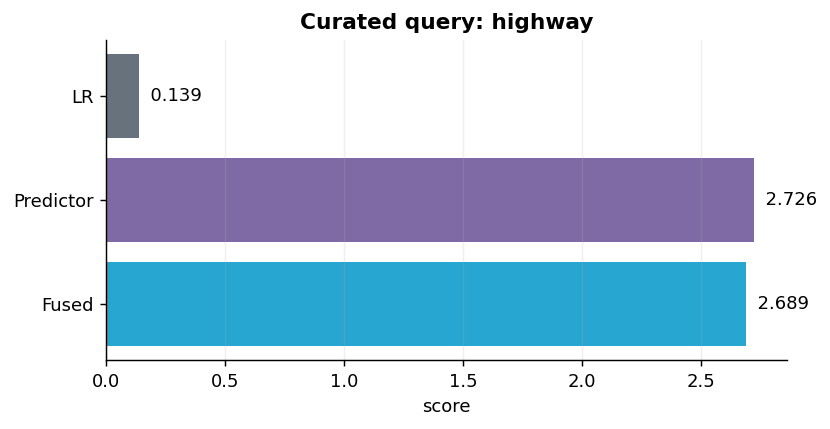

In [9]:
query_scores = pd.DataFrame([{
    "query": query_name,
    "Pc": int(model.pc_policy.values[query_index]),
    "LR": float(result["lr_scores"][query_index]),
    "Predictor": float(result["predictor_scores"][query_index]),
    "Fused": float(result["final_scores"][query_index]),
}])
display(query_scores.round(4))

labels = ["LR", "Predictor", "Fused"]
values = [float(query_scores.iloc[0][label]) for label in labels]
fig, ax = plt.subplots(figsize=(6.5, 3.4))
bars = ax.barh(labels, values, color=[COLORS["gray"], COLORS["purple"], COLORS["blue"]])
ax.invert_yaxis()
ax.set_xlabel("score")
ax.set_title(f"Curated query: {query_name}")
ax.grid(axis="x", alpha=0.2)
for bar, value in zip(bars, values):
    ax.text(value, bar.get_y() + bar.get_height() / 2, f"  {value:.3f}", va="center")
plt.tight_layout()
plt.show()


## 8. Text retrieval

Curated results from a 5,015-scene library. A `predicted` tag marks a location completed from LR and sampled context.


In [10]:
RETRIEVAL_QUERIES = [
    ("golf", "Golf course"),
    ("soccer", "Soccer field"),
    ("baseball", "Baseball field"),
    ("pond", "Pond"),
    ("railroad", "Railroad"),
    ("wetland", "Wetland"),
]
SHOWN_MATCHES = 5
MINIMUM_DISTANCE_KM = 2.0

import json
from safetensors import safe_open

with safe_open(WEIGHTS_DIR / "vision_language_predictor.safetensors", framework="pt", device="cpu") as source:
    metadata = source.metadata() or {}
    retrieval = {
        "format": metadata.get("demo_format"),
        "class_names": tuple(json.loads(metadata["demo_class_names"])),
        "sample_indices": source.get_tensor("demo.sample_indices"),
        "pred_hr_scores": source.get_tensor("demo.pred_hr_scores"),
        "lr_scores": {"mean": source.get_tensor("demo.lr_mean_scores")},
    }
if (
    retrieval.get("format") != "crossso-retrieval-v3"
    or len(retrieval["sample_indices"]) != len(frame)
    or tuple(retrieval["class_names"]) != tuple(CLASS_NAMES)
    or not torch.equal(retrieval["sample_indices"], torch.arange(len(frame)))
):
    raise ValueError("Retrieval library mismatch")

library_scores = fusion.apply(
    retrieval["pred_hr_scores"].float(),
    {name: value.float() for name, value in retrieval["lr_scores"].items()},
    class_names=CLASS_NAMES,
)


def distance_km(first: tuple[float, float], second: tuple[float, float]) -> float:
    lat1, lon1 = np.radians(first)
    lat2, lon2 = np.radians(second)
    value = (
        np.sin((lat2 - lat1) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    )
    return float(12742.0176 * np.arcsin(np.sqrt(value)))


@torch.inference_mode()
def retrieval_evidence(row: pd.Series, class_index: int) -> dict:
    scene_lr, scene_hr = row_paths(row)
    provider = FileHRTileProvider(scene_hr, model_config.image_size)
    prediction = model.predict_pc_query(scene_lr, provider, class_index)
    tile_index = int(prediction.tile_scores[:, class_index].argmax())
    return {
        "Pc": len(prediction.selected_indices),
        "predicted": tile_index not in prediction.selected_indices,
        "path": scene_hr[tile_index],
    }


retrieval_results = {}
used_samples: set[int] = set()
used_locations: list[tuple[float, float]] = []
started = time.perf_counter()

for query, display_name in RETRIEVAL_QUERIES:
    class_index = CLASS_NAMES.index(query)
    order = library_scores[:, class_index].argsort(descending=True)
    matches = []
    for library_position in order.tolist():
        sample = int(retrieval["sample_indices"][library_position])
        row = frame.iloc[sample]
        location = (float(row["lat"]), float(row["lon"]))
        if sample in used_samples or any(
            distance_km(location, other) < MINIMUM_DISTANCE_KM
            for other in used_locations
        ):
            continue
        matches.append(retrieval_evidence(row, class_index))
        used_samples.add(sample)
        used_locations.append(location)
        if len(matches) == SHOWN_MATCHES:
            break
    retrieval_results[query] = {"name": display_name, "matches": matches}

print(
    f"Built a {len(RETRIEVAL_QUERIES)}-query gallery from "
    f"{len(frame):,} scenes in {time.perf_counter() - started:.1f} s"
)


Built a 6-query gallery from 5,015 scenes in 5.1 s


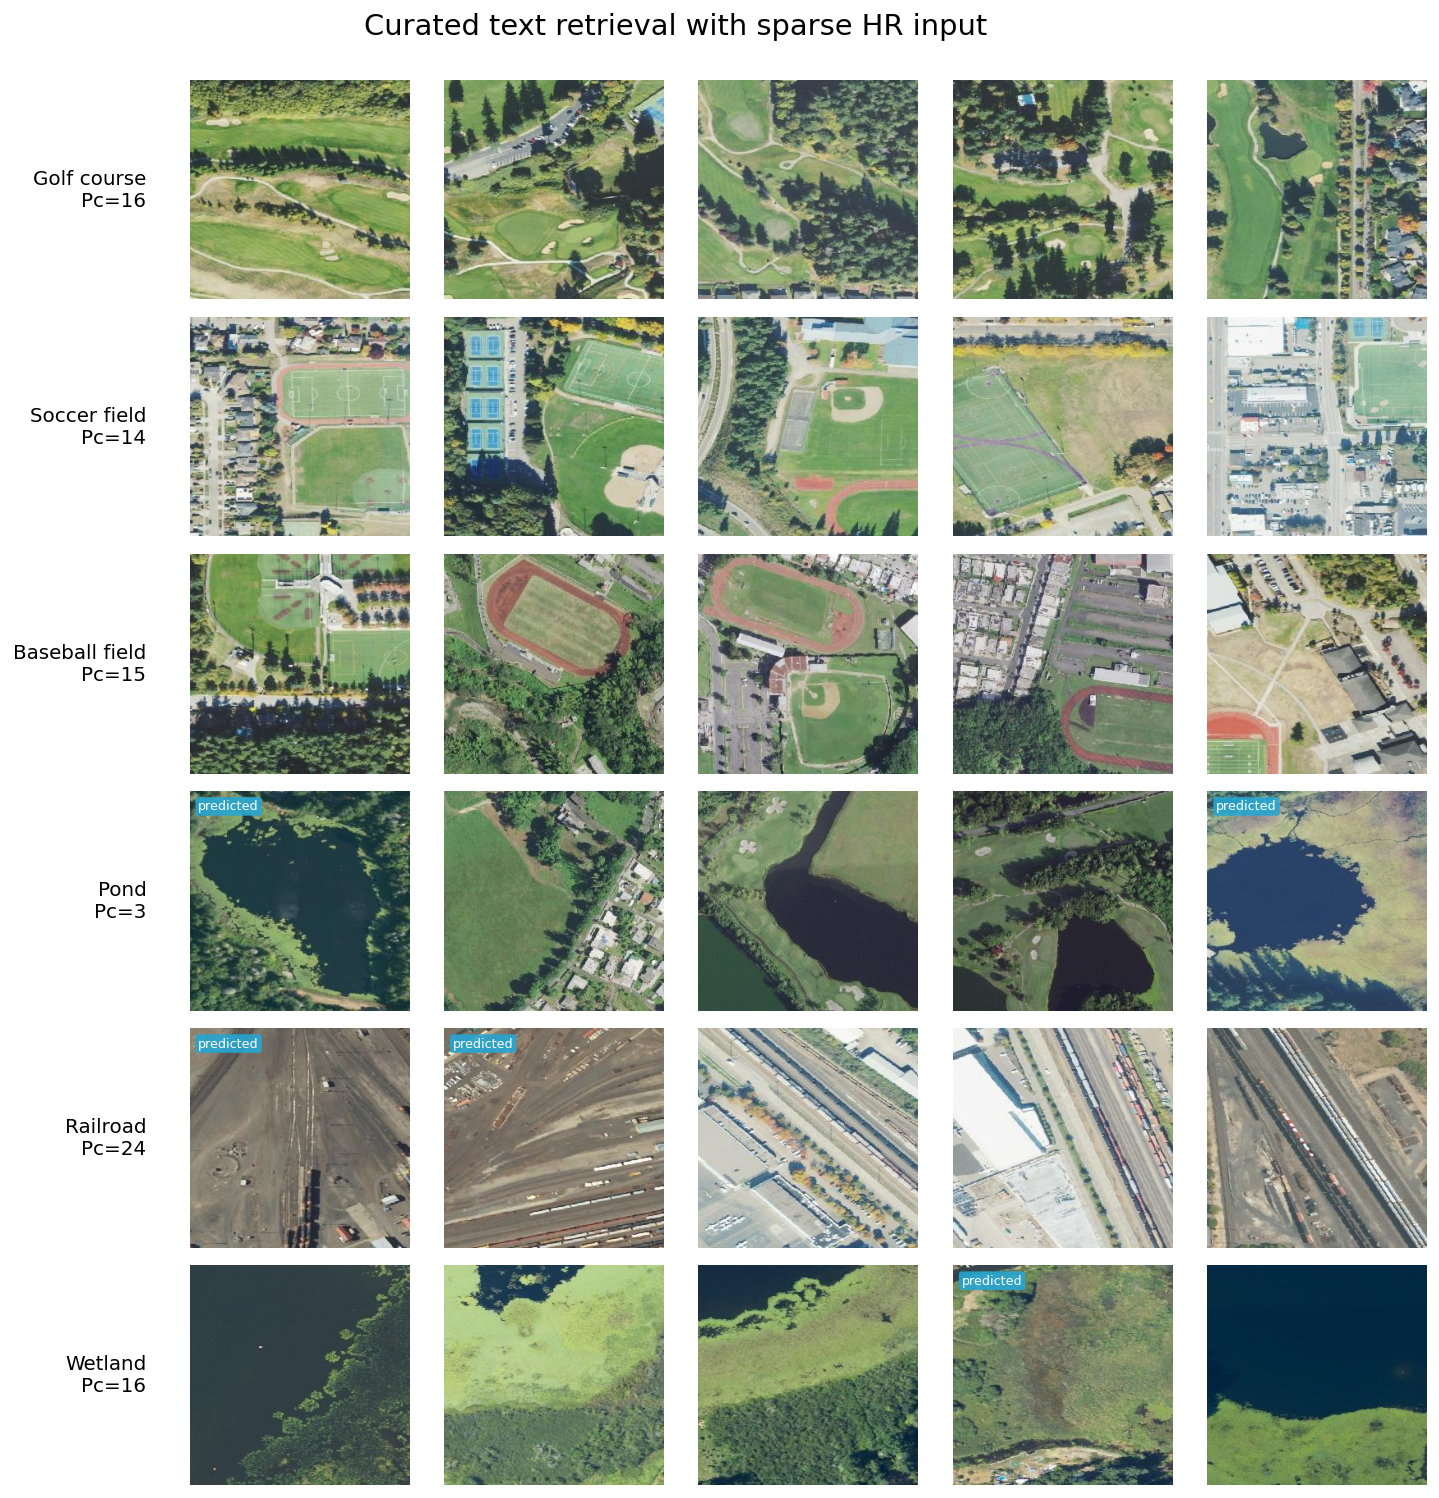

In [11]:
fig, axes = plt.subplots(
    len(RETRIEVAL_QUERIES), SHOWN_MATCHES, figsize=(12, 11.5), squeeze=False
)

for row_index, (query, _) in enumerate(RETRIEVAL_QUERIES):
    item = retrieval_results[query]
    for column_index, match in enumerate(item["matches"]):
        ax = axes[row_index, column_index]
        with Image.open(match["path"]) as source:
            ax.imshow(source.convert("RGB"))
        ax.set_xticks([])
        ax.set_yticks([])
        if match["predicted"]:
            ax.text(
                0.04, 0.96, "predicted",
                transform=ax.transAxes,
                ha="left", va="top", fontsize=7, color="white",
                bbox={
                    "boxstyle": "round,pad=0.22",
                    "facecolor": COLORS["blue"],
                    "edgecolor": "none",
                    "alpha": 0.9,
                },
            )
        for spine in ax.spines.values():
            spine.set_visible(False)
        if column_index == 0:
            ax.set_ylabel(
                f'{item["name"]}\nPc={match["Pc"]}',
                rotation=0, ha="right", va="center", labelpad=24, fontsize=11,
            )

fig.suptitle("Curated text retrieval with sparse HR input", fontsize=16, y=0.995)
plt.subplots_adjust(left=0.18, right=0.99, top=0.95, bottom=0.01, wspace=0.035, hspace=0.08)

retrieval_figure_path = OUTPUT_DIR / "budgeted-retrieval.png"
fig.savefig(retrieval_figure_path, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()


## Notes

- `Pc` is the number of HR tiles read from 100 candidates.
- The latent cosine is a one-scene same-encoder proxy.
- Gallery entries are score-ranked and geographically deduplicated without labels; they are qualitative examples, not an accuracy estimate.
- For a `predicted` entry, the image reveals the unsampled location represented by the completed feature.
- Set `CROSSSO_DEVICE=cpu` when CUDA is unavailable.
